<a href="https://colab.research.google.com/github/eduardofmj97/EBAC/blob/main/Decision_tree(M21EBAC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [2]:
X_test = pd.read_csv("X_test.csv", delimiter=',')
X_train = pd.read_csv("X_train_balanced.csv", delimiter=',')
y_test = pd.read_csv("y_test.csv", delimiter=',')
y_train = pd.read_csv("y_train_balanced.csv", delimiter=',')

In [5]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    41 non-null     float64
 1   Income                 41 non-null     float64
 2   Education              41 non-null     int64  
 3   Number of Children     41 non-null     int64  
 4   Marital Status_Single  41 non-null     int64  
 5   Home Ownership_Rented  41 non-null     int64  
 6   Gender_Male            41 non-null     int64  
dtypes: float64(2), int64(5)
memory usage: 2.4 KB


In [8]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    252 non-null    float64
 1   Income                 252 non-null    float64
 2   Education              252 non-null    int64  
 3   Number of Children     252 non-null    int64  
 4   Marital Status_Single  252 non-null    int64  
 5   Home Ownership_Rented  252 non-null    int64  
 6   Gender_Male            252 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 13.9 KB


In [7]:
y_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Credit Score  252 non-null    int64
dtypes: int64(1)
memory usage: 2.1 KB


In [6]:
y_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Credit Score  41 non-null     int64
dtypes: int64(1)
memory usage: 460.0 bytes


In [9]:
count_test = y_test.value_counts()
count_train = y_train.value_counts()
print("Contagem de amostras por classe no teste:")
print(count_test)
print("Contagem de amostras por classe no treino:")
print(count_train)

Contagem de amostras por classe no teste:
Credit Score
2               29
0                6
1                6
Name: count, dtype: int64
Contagem de amostras por classe no treino:
Credit Score
0               84
1               84
2               84
Name: count, dtype: int64


# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

Primeiramente, fazemos a seleção dos dados do modelo através da limpeza de outliers, tratamento de valores nulos e demais correções que forem necessárias na base de dados. Então, fazemos a preparação dos dados através da separação em variável alvo (target) e as variáveis de entrada (features). Dividimos em treino e teste para construirmos o modelo e avaliarmos seu desempenho.
Com a base pronta, então construimos a árvore de decisões, que é o algoritmo que escolhe a melhor forma de separação de dados de acordo com as variáveis e critérios pré-definidos (entropy, indíce de gini) que medem a pureza dos grupos.
Finalmente então realizamos as previsões, onde a árvore classifica novos dados seguindo as regras estabelecidas até chegarmos a previsão da classe (folha) de um novo dado.
Após isso, avaliamos as métricas do modelo, como acurácia, precisão, recall, f1-score para determinar sua qualidade.
Para melhorarmos o modelo, podemos ajustar parâmetros como profundidade da árvore, número mínimo de amostras, fazer a poda para evitar overfitting, remover ruído dos dados e selecionar variáveis mais influentes.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [10]:
credit_tree = DecisionTreeClassifier(criterion='gini', random_state=0)
credit_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [13]:
accuracy_train = credit_tree.score(X_train, y_train)
print("Acurácia do modelo:", accuracy)

Acurácia do modelo: 1.0


# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [14]:
predict = credit_tree.predict(X_test)
accuracy_test = accuracy_score(y_test, predict)
print("Acurácia do modelo:", accuracy_test)

Acurácia do modelo: 0.9512195121951219


O modelo apresentou desempenho perfeito nos dados de treino e houve uma leve queda nos dados de teste, tendo acurácia de 95%. O desempenho de 100% nos dados de treino podem indicar overfitting, mas pode generalizar muito bem no teste.

In [23]:
relatorio = classification_report(y_test, predict)
print('Relatório de classificação:')
print(relatorio)

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.75      1.00      0.86         6
           2       1.00      0.93      0.96        29

    accuracy                           0.95        41
   macro avg       0.92      0.98      0.94        41
weighted avg       0.96      0.95      0.95        41



# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

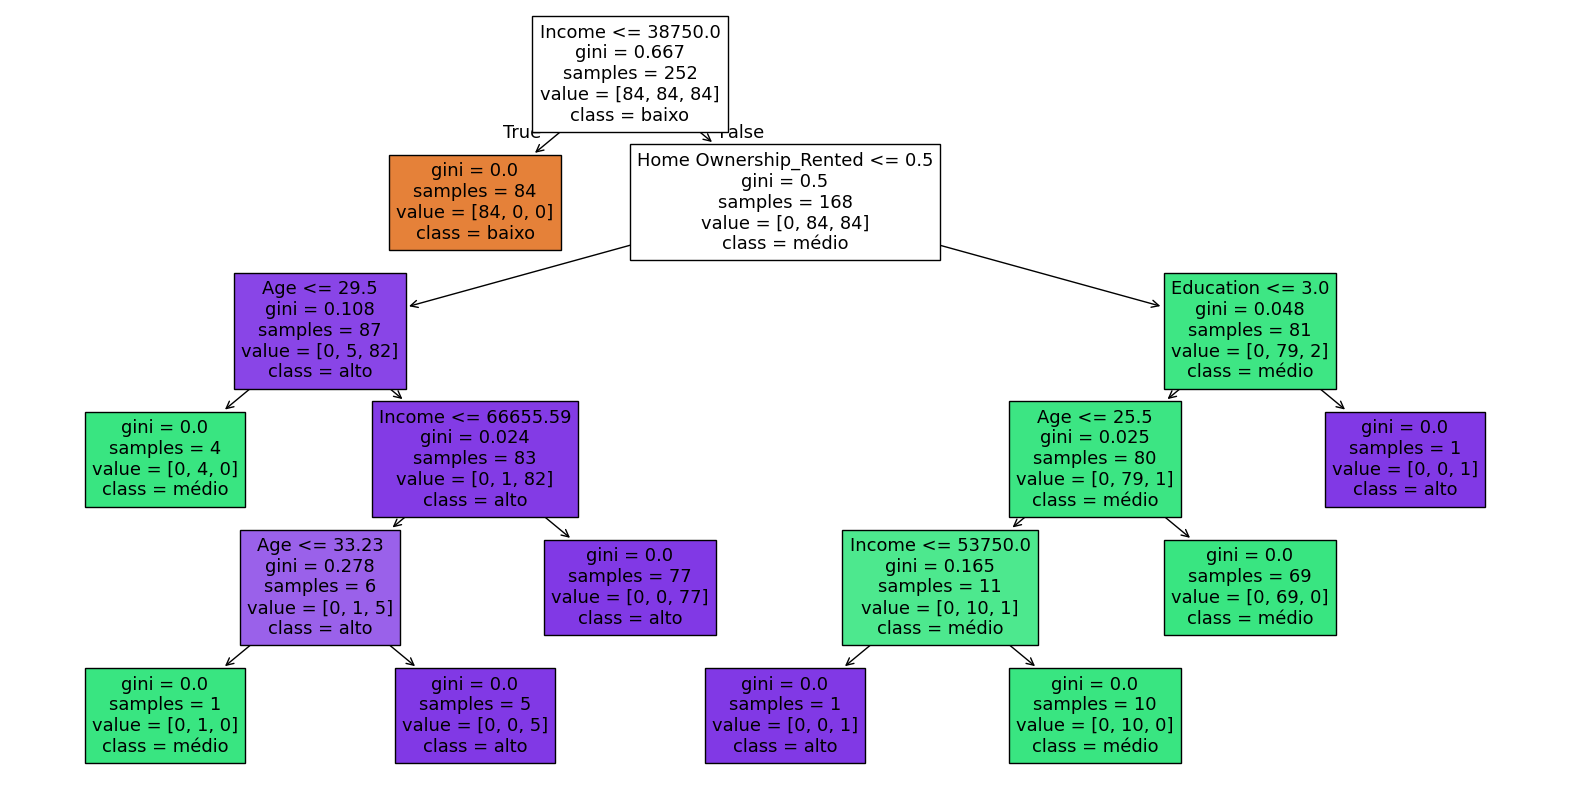

In [15]:
plt.figure(figsize=(20,10))
plot_tree(credit_tree, filled=True, feature_names=X_train.columns, class_names=['baixo', 'médio', 'alto'])
plt.show()

Sim, é possível fazer a avaliação visual visto que o modelo apresenta poucas features, contando com uma profundidade de 5.

# 6) Identifique as 2 principais features do modelo.


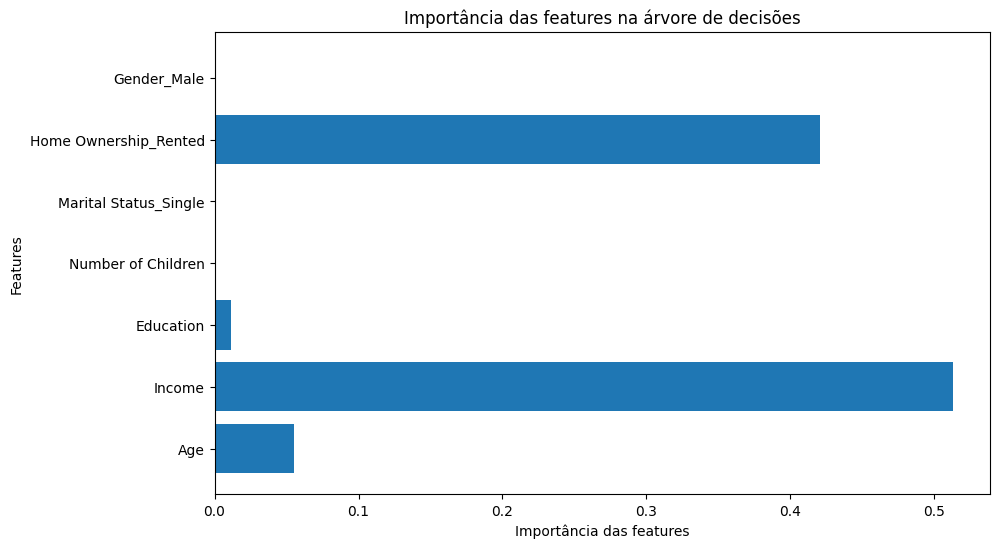

In [16]:
feature_importance = credit_tree.feature_importances_
feature_names = X_train.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance)
plt.xlabel('Importância das features')
plt.ylabel('Features')
plt.title('Importância das features na árvore de decisões')
plt.show()

As principis features são Home Ownership (Rented) seguida de Income

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [19]:
X_train_reduzido = X_train[['Home Ownership_Rented', 'Income']]
X_test_reduzido = X_test[['Home Ownership_Rented', 'Income']]

In [20]:
credit_tree_reduzido = DecisionTreeClassifier(criterion='gini', random_state=0)
credit_tree_reduzido.fit(X_train_reduzido, y_train)

DecisionTreeClassifier(random_state=0)

In [21]:
previsao_reduzida = credit_tree_reduzido.predict(X_test_reduzido)

In [22]:
relatorio = classification_report(y_test, previsao_reduzida)
print('Relatório de classificação:')
print(relatorio)

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.83      0.83      0.83         6
           2       0.97      0.97      0.97        29

    accuracy                           0.95        41
   macro avg       0.93      0.93      0.93        41
weighted avg       0.95      0.95      0.95        41



O desempenho da árvore se demonstrou muito próximo ao modelo anterior, sem o isolamento das features. Houve uma queda de 5% na média de acertos do recall, com uma melhoria de somente 1% na precisão. O modelo antes do isolamento, para esse caso, se mostrou mais eficaz uma vez que o recall é maior e os dados estão tratando da análise de crédito. O modelo conseguiu detectar 98% dos score, em média, de forma correta antes do isolamento.

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

O modelo de Naive Bayes apresentou uma acurácia e recall de 100% nos dados de teste no último estudo, fazendo com que a análise tenha sido perfeitamente adequada, porém isso pode ser indicativo de que algum erro analítico aconteceu, como a base de dados ter sido pequena demais, dados muito simples ou overfitting por possivelmente haver features irrelevantes, o que pode ser explicado por ser uma base pequena e artificial.
Já a árvore de decisões demonstra um resultado mais realista, tanto com os conjuntos de features completos ou reduzidos, garantindo um recall alto que é o ponto mais importante nessa análise de crédito, como explicado anteriormente.